# t-SNE of top-5 overall force-constant solutions

This notebook performs t-SNE on the five-dimensional BvK force-constant vectors
\[
(\alpha_0,\alpha_1,\beta_1,\alpha_2,\beta_2)
\]
for the top five overall solutions from `dataframe000013.pkl` and `dataframe000014.pkl` for each \((m,a)\) pair.

The goal is to test whether the two \((\alpha_2,\beta_2)\) families appear as separated nonlinear neighborhoods in force-constant space.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = "retina"

DATA_DIR = Path("./dataframes/")  # Update if needed.

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
}

TOP_K = 5
RANK_BY = "fitness_norm"

SAVE_FORMATS = ("pdf", "png")
DPI = 300

FIGSIZE = (6.2, 5.2)
MARKER_SIZE = 58
MARKER_ALPHA = 0.86
EDGE_WIDTH = 0.3
ZERO_TOL = 0.08


In [2]:
def find_first_existing(candidates, columns):
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}. Update DATA_DIR or DATAFRAME_FILES.")
    df = pd.read_pickle(path).copy()
    df["dataset"] = dataset_label
    return df


def display_label(col):
    label_map = {
        "mass": r"$m$ (amu)", "m": r"$m$ (amu)",
        "a_val": r"$a$ ($\AA$)", "alat": r"$a$ ($\AA$)",
        "a_latt": r"$a$ ($\AA$)", "lattice_parameter": r"$a$ ($\AA$)",
        "alpha0": r"$\alpha_0$ (N/m)", "alpha_0": r"$\alpha_0$ (N/m)",
        "alpha1": r"$\alpha_1$ (N/m)", "alpha_1": r"$\alpha_1$ (N/m)",
        "beta1": r"$\beta_1$ (N/m)", "beta_1": r"$\beta_1$ (N/m)",
        "alpha2": r"$\alpha_2$ (N/m)", "alpha_2": r"$\alpha_2$ (N/m)",
        "beta2": r"$\beta_2$ (N/m)", "beta_2": r"$\beta_2$ (N/m)",
        "fitness_norm": r"$f_{\mathrm{norm}}$", "fnorm": r"$f_{\mathrm{norm}}$",
        "r_alpha2": r"$r_{\alpha_2}$",
    }
    return label_map.get(col, col)


def apply_publication_axes(ax):
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True,
                   labelsize=12, length=5, width=1.1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)


def save_figure(fig, stem, output_dir, formats=SAVE_FORMATS):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    print("Saved:")
    for path in saved:
        print(f"  {path}")
    return saved


def classify_family(row, alpha2_col, beta2_col):
    a2 = row[alpha2_col]
    b2 = row[beta2_col]
    if abs(b2) <= ZERO_TOL and abs(a2) > ZERO_TOL:
        return r"$\alpha_2$-dominated"
    if abs(a2) <= ZERO_TOL and abs(b2) > ZERO_TOL:
        return r"$\beta_2$-dominated"
    if abs(a2) > abs(b2):
        return r"$\alpha_2$ larger"
    if abs(b2) > abs(a2):
        return r"$\beta_2$ larger"
    return "balanced"


In [3]:
frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe before filtering: {df_all.shape[0]:,} rows")

mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

alpha0_col = find_first_existing(["alpha0", "alpha_0"], df_all.columns)
alpha1_col = find_first_existing(["alpha1", "alpha_1"], df_all.columns)
beta1_col  = find_first_existing(["beta1", "beta_1"], df_all.columns)
alpha2_col = find_first_existing(["alpha2", "alpha_2"], df_all.columns)
beta2_col  = find_first_existing(["beta2", "beta_2"], df_all.columns)

force_constant_cols = [alpha0_col, alpha1_col, beta1_col, alpha2_col, beta2_col]

required = [mass_col, alat_col, rank_col] + force_constant_cols
if any(col is None for col in required):
    raise ValueError("Could not detect all required columns. Check dataframe column names.")

print("\nForce-constant columns:")
for col in force_constant_cols:
    print(f"  {col}")

df_top = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

for col in [mass_col, alat_col, rank_col] + force_constant_cols:
    df_top[col] = pd.to_numeric(df_top[col], errors="coerce")

df_top = df_top.dropna(subset=[mass_col, alat_col, rank_col] + force_constant_cols).copy()

df_top["abs_alpha2"] = df_top[alpha2_col].abs()
df_top["abs_beta2"] = df_top[beta2_col].abs()
df_top["r_alpha2"] = df_top["abs_alpha2"] / (df_top["abs_alpha2"] + df_top["abs_beta2"] + 1e-12)
df_top["delta_alpha2_beta2"] = df_top["abs_alpha2"] - df_top["abs_beta2"]
df_top["family"] = df_top.apply(lambda row: classify_family(row, alpha2_col, beta2_col), axis=1)

print(f"\nRows after top-{TOP_K}-overall selection: {df_top.shape[0]:,}")
print(df_top["family"].value_counts())

X = df_top[force_constant_cols].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe before filtering: 420,000 rows

Force-constant columns:
  alpha0
  alpha1
  beta1
  alpha2
  beta2

Rows after top-5-overall selection: 840
family
$\beta_2$-dominated     600
$\alpha_2$-dominated    205
$\beta_2$ larger         20
$\alpha_2$ larger        15
Name: count, dtype: int64


In [4]:
from sklearn.manifold import TSNE

OUTPUT_DIR = Path("tsne_force_constant_space_top5_overall")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N = X_scaled.shape[0]
PERPLEXITY = min(20, max(5, (N - 1) // 4))
RANDOM_STATE = 42

print(f"Number of samples: {N}")
print(f"Using perplexity: {PERPLEXITY}")

tsne = TSNE(
    n_components=2,
    perplexity=PERPLEXITY,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
    metric="euclidean",
)

embedding = tsne.fit_transform(X_scaled)
df_top["tSNE1"] = embedding[:, 0]
df_top["tSNE2"] = embedding[:, 1]
df_top[["dataset", mass_col, alat_col, rank_col, "tSNE1", "tSNE2", "r_alpha2", "family"]].head()


Number of samples: 840
Using perplexity: 20


,dataset,mass,a_val,fitness_norm,tSNE1,tSNE2,r_alpha2,family
214621,dataframe000015,50.0,2.2,1.731862,-14.080329,-36.721992,0.000249,$\beta_2$-dominated
214938,dataframe000015,50.0,2.2,1.731862,-15.809656,-37.722881,0.000249,$\beta_2$-dominated
214926,dataframe000015,50.0,2.2,1.731862,-15.400686,-36.600857,0.000249,$\beta_2$-dominated
214927,dataframe000015,50.0,2.2,1.731862,-17.229805,-28.380102,0.000249,$\beta_2$-dominated
214928,dataframe000015,50.0,2.2,1.731862,-14.677377,-37.869556,0.000249,$\beta_2$-dominated


Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_lattice_parameter.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_lattice_parameter.png


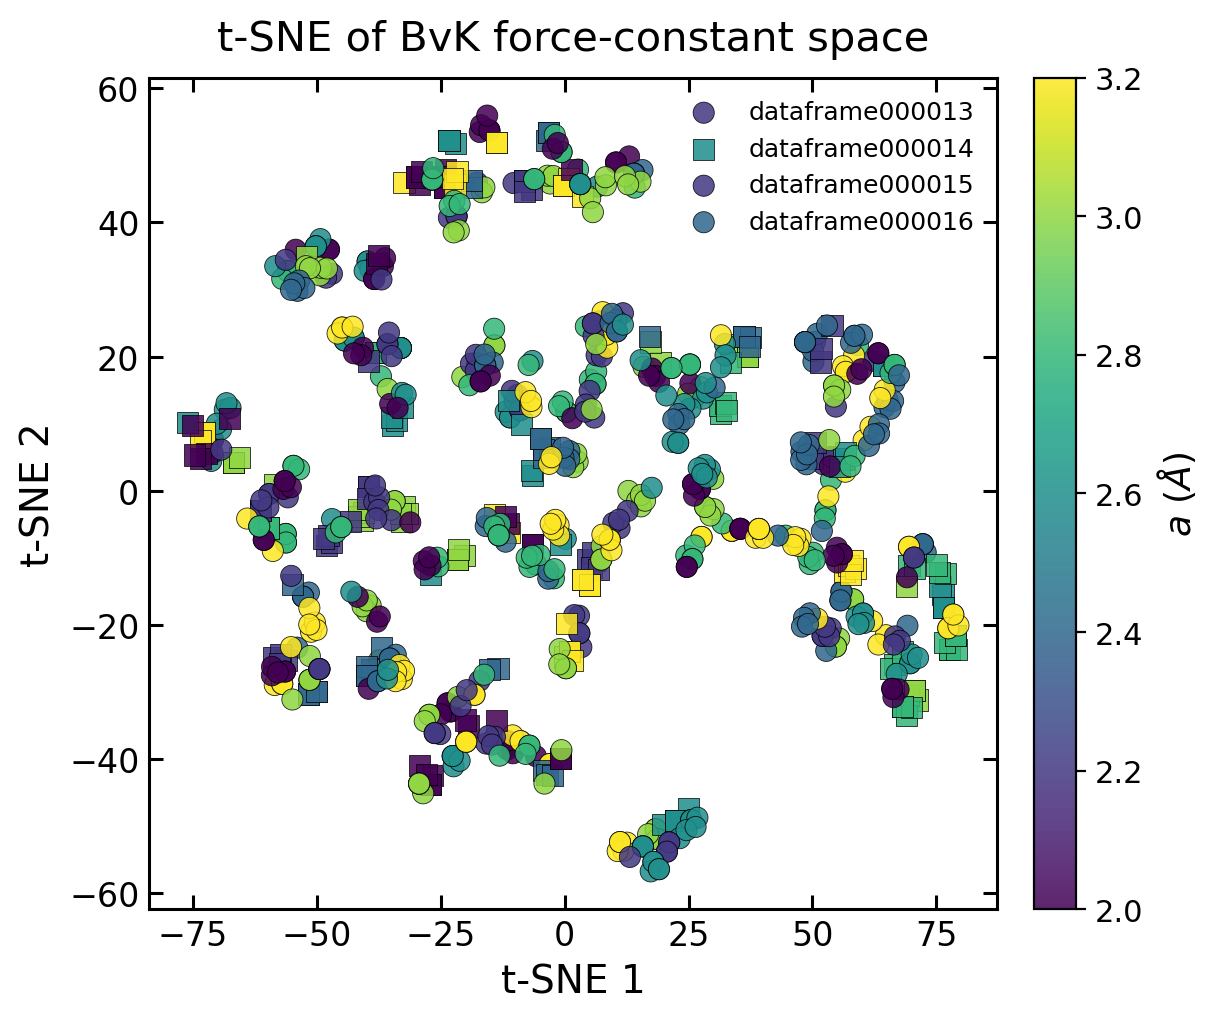

Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_mass.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_mass.png


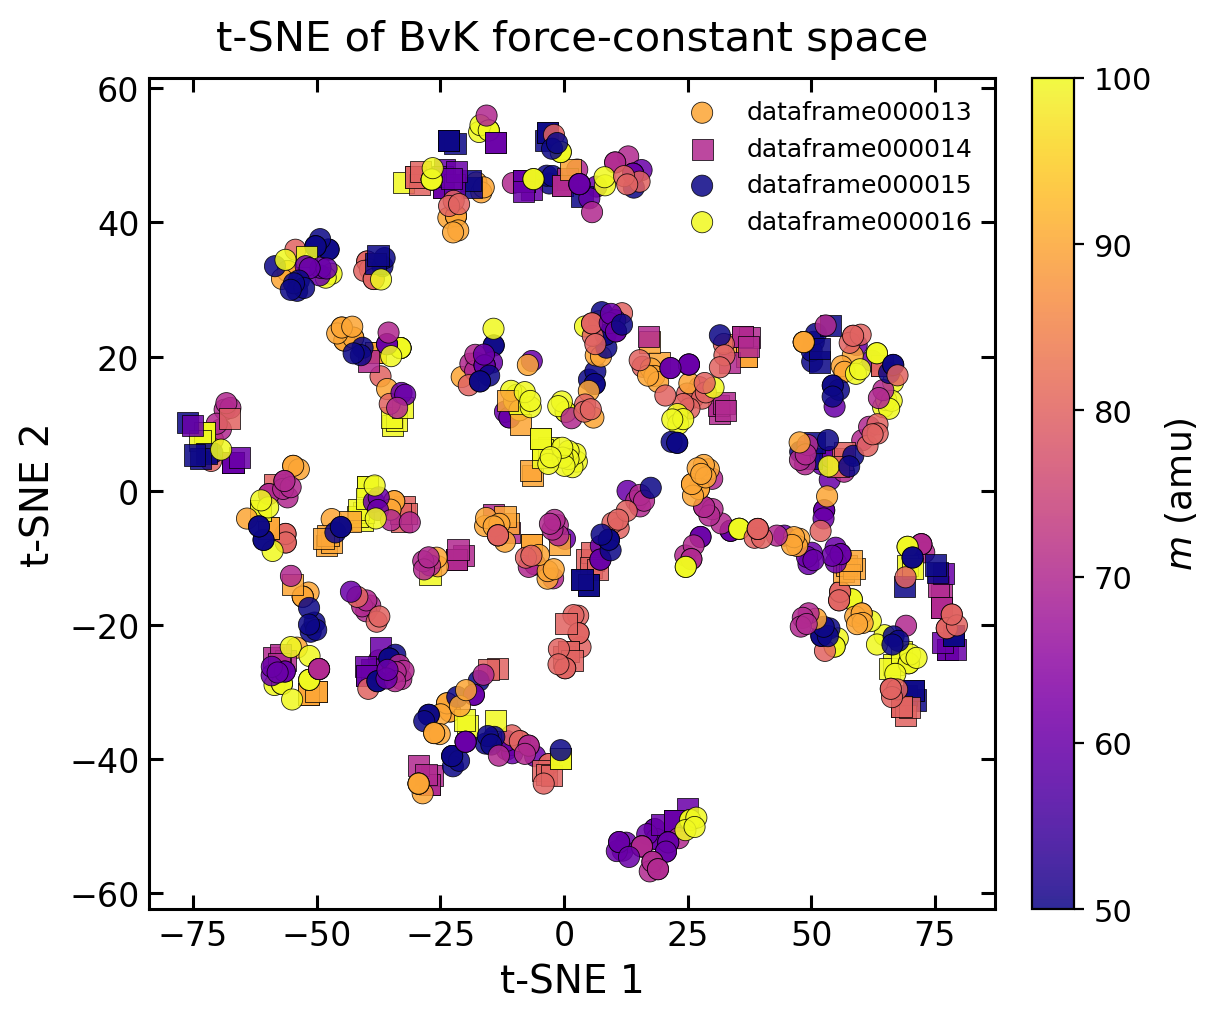

Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2.png


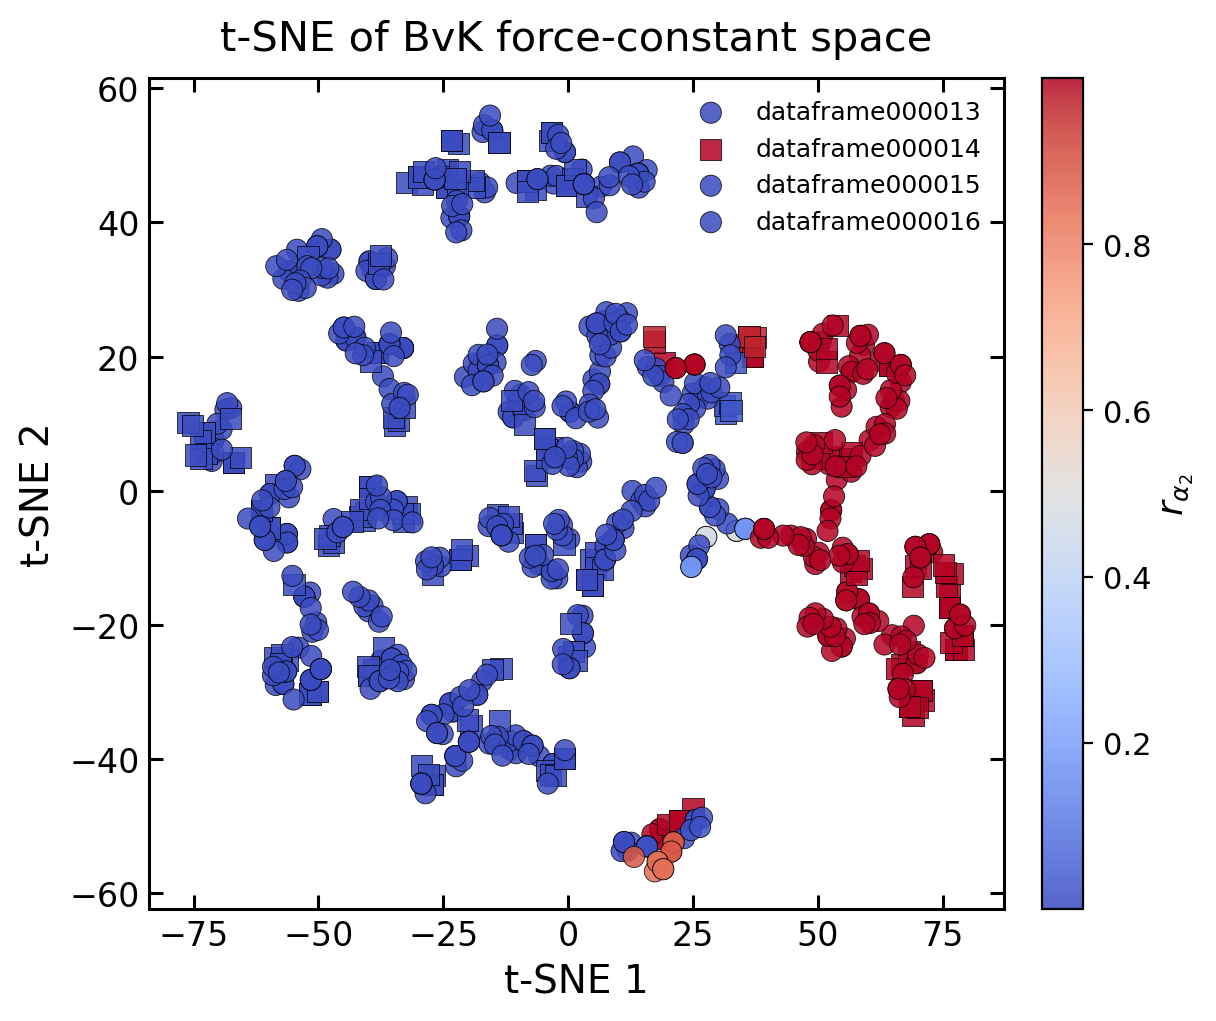

In [5]:
def plot_tsne_scatter(color_col, cmap, stem, color_label=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    c_all = df_top[color_col].astype(float)
    markers = {"dataframe000013": "o", "dataframe000014": "s"}
    scatter_ref = None

    for dataset_label, sub in df_top.groupby("dataset"):
        sc = ax.scatter(
            sub["tSNE1"], sub["tSNE2"],
            c=sub[color_col].astype(float),
            cmap=cmap, vmin=c_all.min(), vmax=c_all.max(),
            s=MARKER_SIZE, alpha=MARKER_ALPHA,
            edgecolors="black", linewidths=EDGE_WIDTH,
            marker=markers.get(dataset_label, "o"),
            label=dataset_label,
        )
        scatter_ref = sc

    ax.set_xlabel("t-SNE 1", fontsize=14)
    ax.set_ylabel("t-SNE 2", fontsize=14)
    ax.set_title("t-SNE of BvK force-constant space", fontsize=15, pad=10)
    apply_publication_axes(ax)
    ax.legend(frameon=False, fontsize=9, loc="best")

    cbar = fig.colorbar(scatter_ref, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(color_label or display_label(color_col), fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    fig.tight_layout()
    save_figure(fig, stem, OUTPUT_DIR)
    plt.show()

plot_tsne_scatter(alat_col, "viridis", "tsne_colored_by_lattice_parameter", r"$a$ ($\AA$)")
plot_tsne_scatter(mass_col, "plasma", "tsne_colored_by_mass", r"$m$ (amu)")
plot_tsne_scatter("r_alpha2", "coolwarm", "tsne_colored_by_r_alpha2", r"$r_{\alpha_2}$")


Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_family.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_family.png


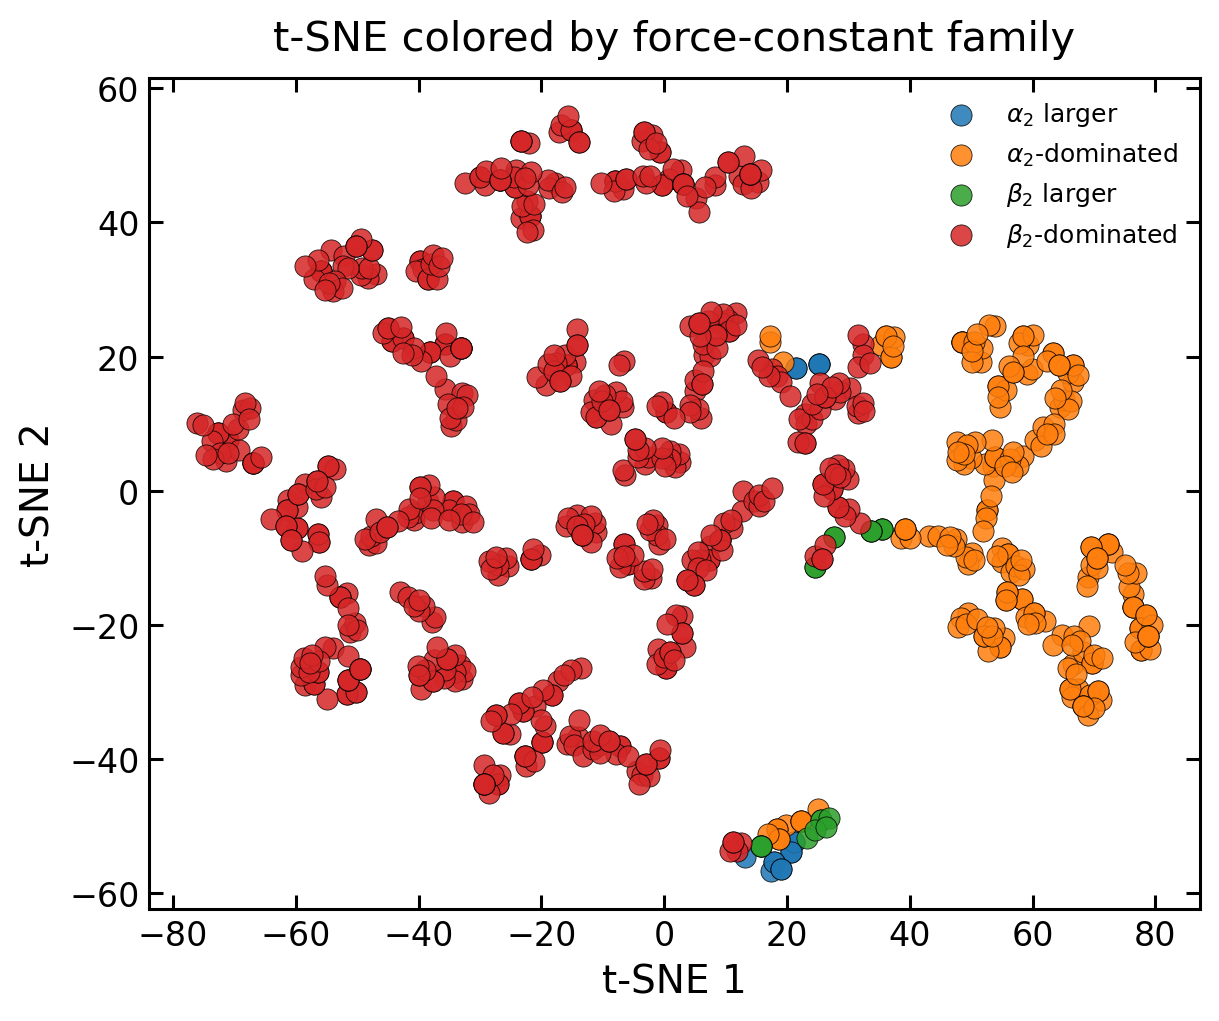

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for family, sub in df_top.groupby("family"):
    ax.scatter(
        sub["tSNE1"], sub["tSNE2"],
        s=MARKER_SIZE, alpha=MARKER_ALPHA,
        edgecolors="black", linewidths=EDGE_WIDTH,
        label=family,
    )

ax.set_xlabel("t-SNE 1", fontsize=14)
ax.set_ylabel("t-SNE 2", fontsize=14)
ax.set_title("t-SNE colored by force-constant family", fontsize=15, pad=10)
apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
save_figure(fig, "tsne_colored_by_family", OUTPUT_DIR)
plt.show()


Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_5.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_5.png


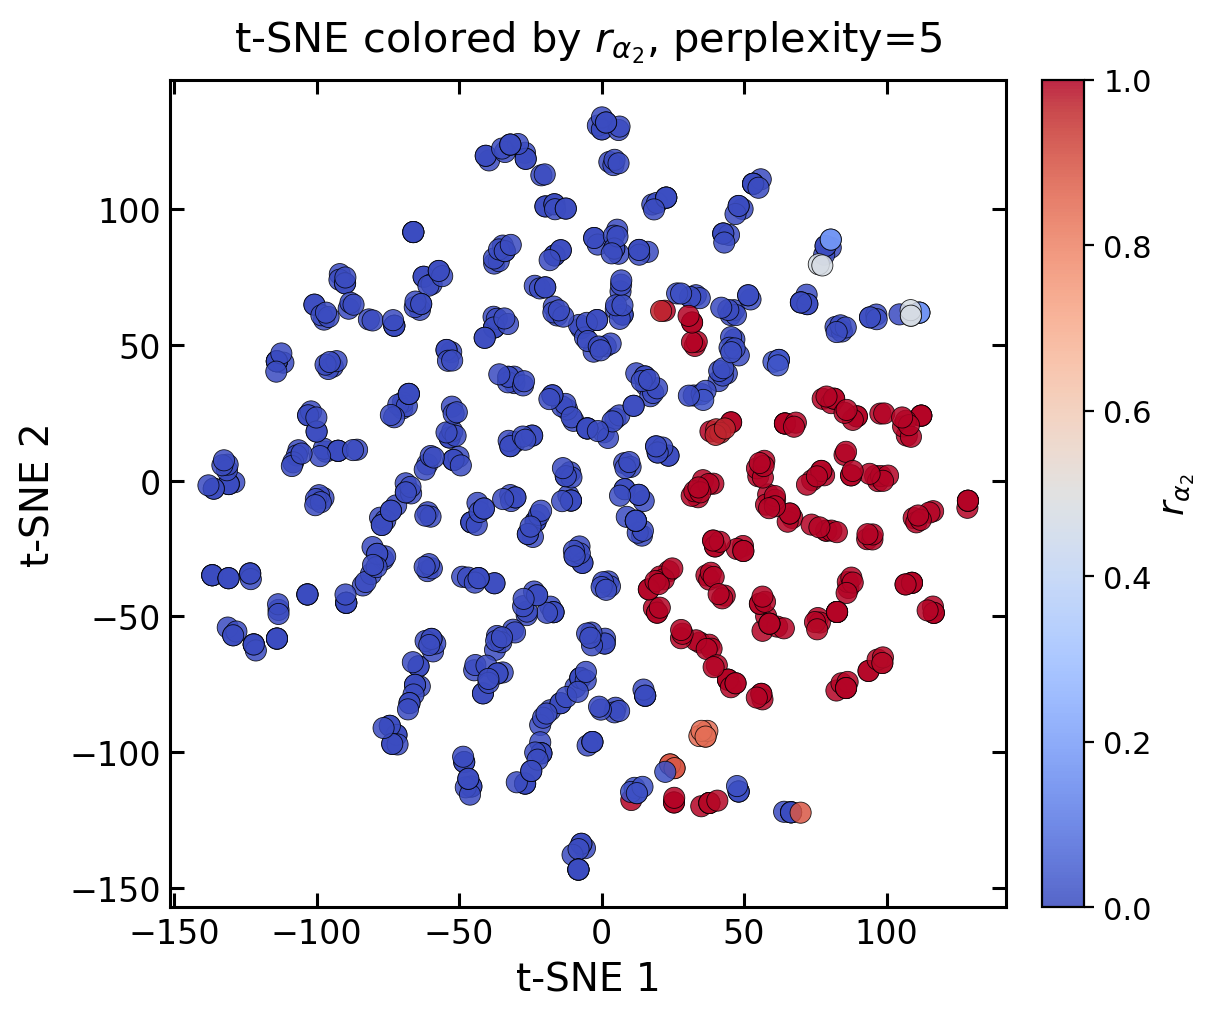

Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_10.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_10.png


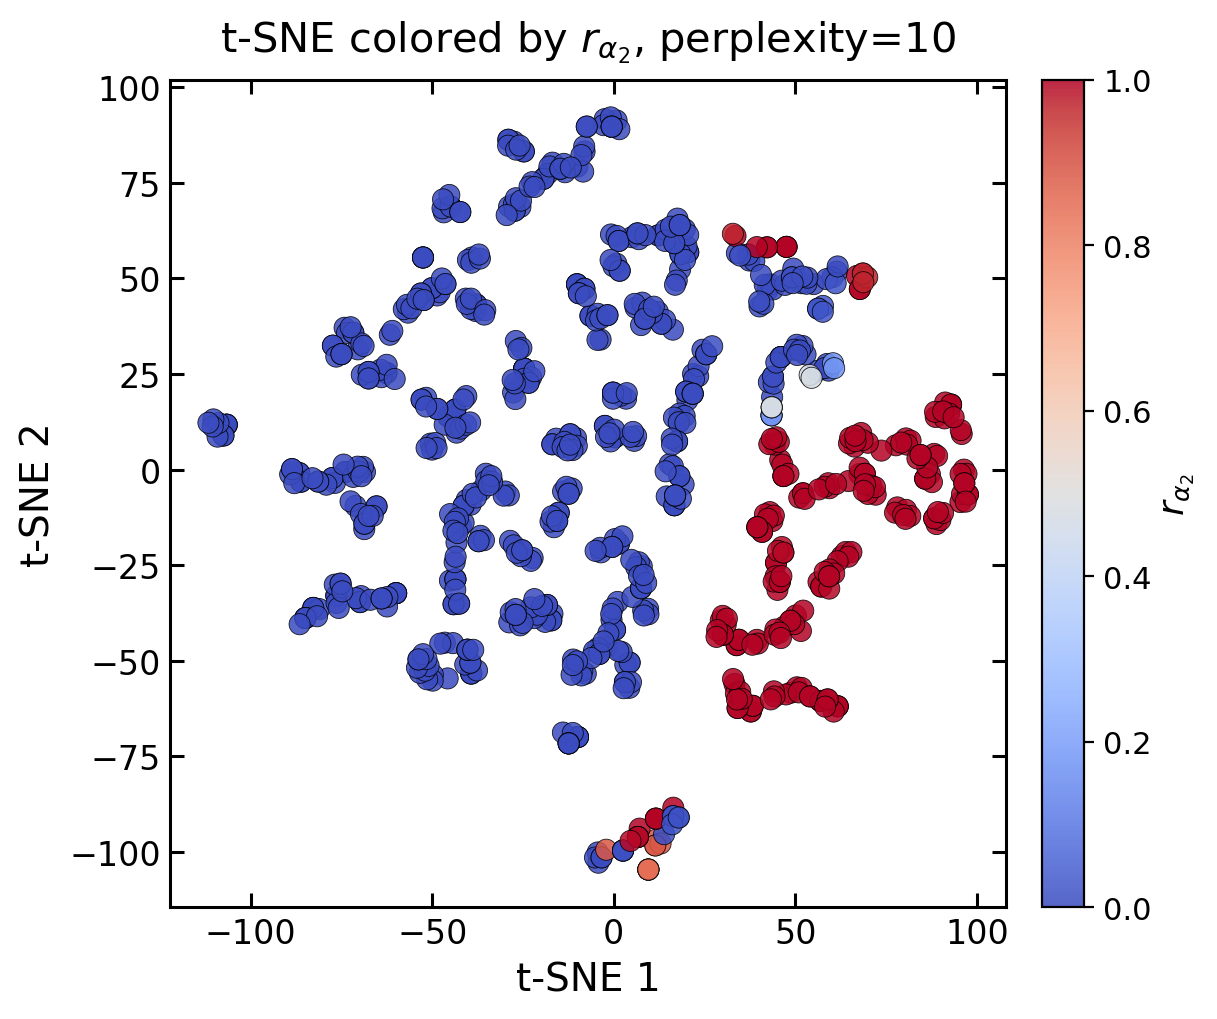

Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_15.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_15.png


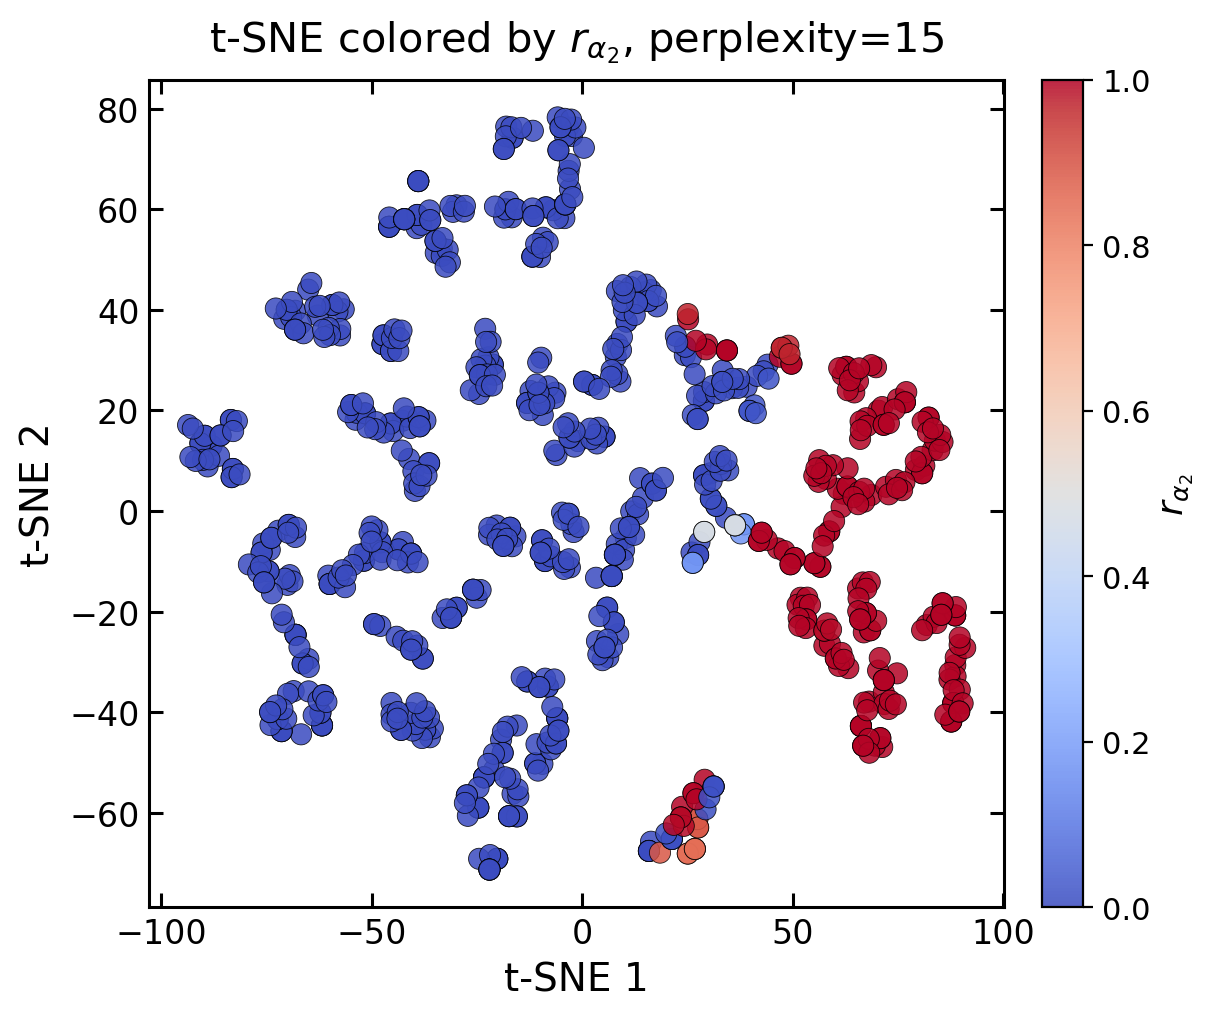

Saved:
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_20.pdf
  tsne_force_constant_space_top5_overall/tsne_colored_by_r_alpha2_perplexity_20.png


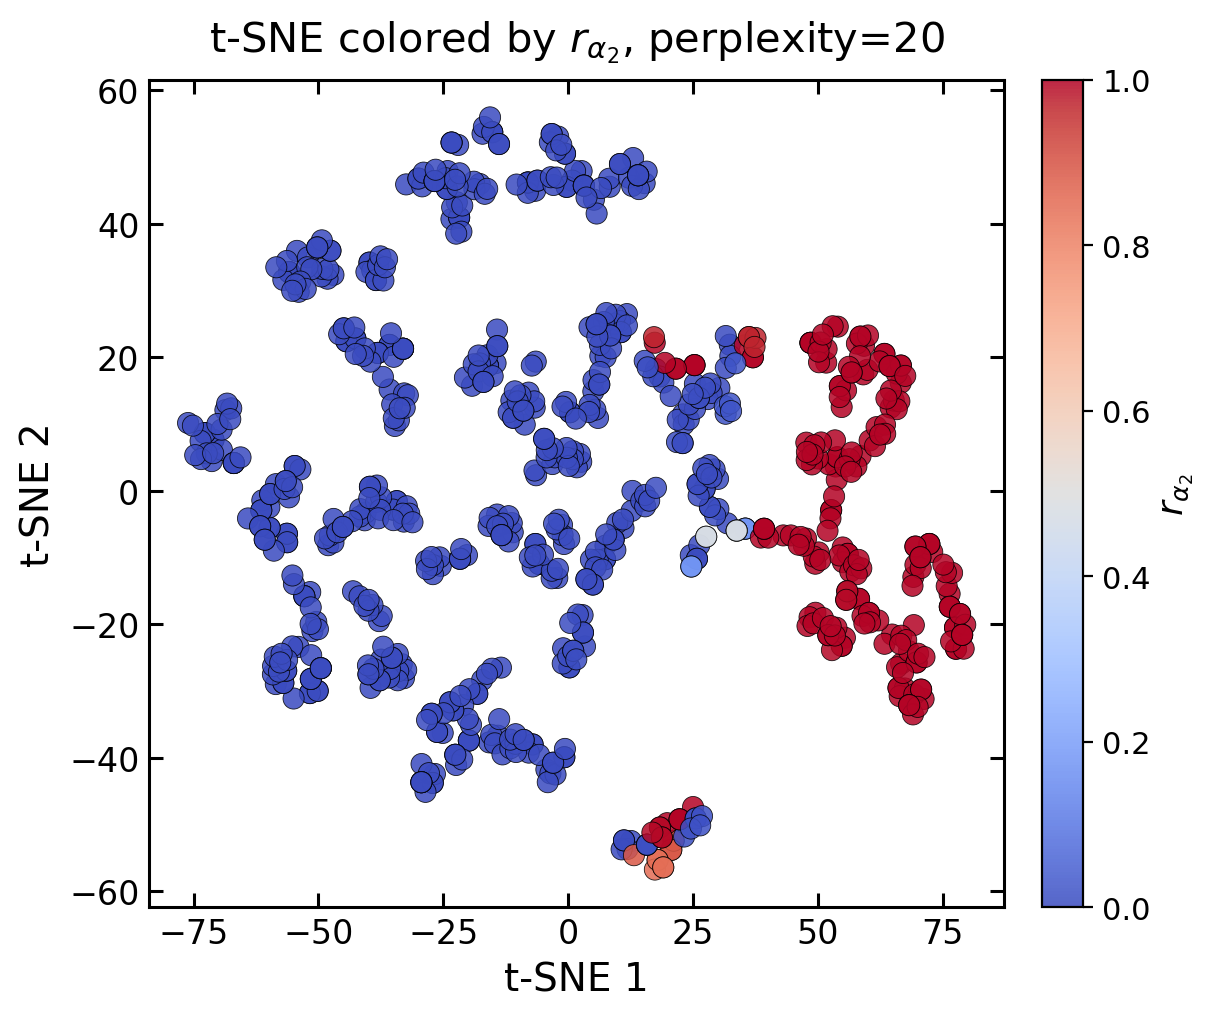

In [7]:
candidate_perplexities = sorted(set([5, 10, 15, 20, PERPLEXITY]))
candidate_perplexities = [p for p in candidate_perplexities if p < N]

for p in candidate_perplexities:
    tsne_p = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE,
        metric="euclidean",
    )
    emb_p = tsne_p.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    sc = ax.scatter(
        emb_p[:, 0], emb_p[:, 1],
        c=df_top["r_alpha2"],
        cmap="coolwarm", vmin=0, vmax=1,
        s=MARKER_SIZE, alpha=MARKER_ALPHA,
        edgecolors="black", linewidths=EDGE_WIDTH,
    )

    ax.set_xlabel("t-SNE 1", fontsize=14)
    ax.set_ylabel("t-SNE 2", fontsize=14)
    ax.set_title(f"t-SNE colored by $r_{{\\alpha_2}}$, perplexity={p}", fontsize=15, pad=10)
    apply_publication_axes(ax)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$r_{\alpha_2}$", fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    fig.tight_layout()
    save_figure(fig, f"tsne_colored_by_r_alpha2_perplexity_{p}", OUTPUT_DIR)
    plt.show()

df_top.to_csv(OUTPUT_DIR / "tsne_embedding_top5_overall.csv", index=False)
